In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics

import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from ultralytics import YOLO

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 69.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
import torch
from ultralytics import YOLO

model_path = "/content/drive/MyDrive/Projects/Object-based ID Tracker (Computer Vision)/Best Model.pt"

model = YOLO(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Model loaded successfully!")
print(f"Using device: {device}")

Model loaded successfully!
Using device: cuda


In [ ]:
print("Upload an image to test the model:")
uploaded = files.upload()

image_filename = list(uploaded.keys())[0]
print(f"Uploaded file: {image_filename}")

Upload an image to test the model:


Saving progrid-variation-1-1770574047231.png to progrid-variation-1-1770574047231.png
Uploaded file: progrid-variation-1-1770574047231.png


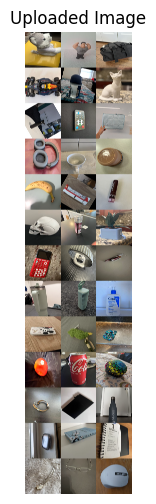

Image tensor shape: torch.Size([1, 3, 640, 640])


In [ ]:
# Cell 4: Preprocess the Image

image = Image.open(image_filename).convert('RGB')

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.title("Uploaded Image")
plt.axis('off')
plt.show()

# Define preprocessing transforms
# ADJUST THESE BASED ON YOUR MODEL'S TRAINING SETTINGS
preprocess = transforms.Compose([
    transforms.Resize((640, 640)),  # Adjust size based on your model's input
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet defaults
                        std=[0.229, 0.224, 0.225])
])

# Preprocess the image
image_tensor = preprocess(image).unsqueeze(0)  # Add batch dimension
image_tensor = image_tensor.to(device)

print(f"Image tensor shape: {image_tensor.shape}")

# Inference with Tiling

In [ ]:
import cv2
import torch
import numpy as np

image_filename = list(uploaded.keys())[0]
img = cv2.imread(image_filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print(f"Original image size: {img_rgb.shape}")

tile_size = 640
overlap = 64

all_detections = []
h, w = img_rgb.shape[:2]

# Create tiles
for y in range(0, h, tile_size - overlap):
    for x in range(0, w, tile_size - overlap):
        x_end = min(x + tile_size, w)
        y_end = min(y + tile_size, h)

        tile = img_rgb[y:y_end, x:x_end]

        # Pad tile if it's smaller than tile_size
        if tile.shape[0] < tile_size or tile.shape[1] < tile_size:
            tile = cv2.copyMakeBorder(tile, 0, tile_size - tile.shape[0],
                                      0, tile_size - tile.shape[1],
                                      cv2.BORDER_CONSTANT, value=(0,0,0))

        # Convert to PIL and save temporarily
        from PIL import Image as PILImage
        tile_pil = PILImage.fromarray(tile)
        tile_pil.save('temp_tile.jpg')

        # Run inference
        results = model('temp_tile.jpg', conf=0.70)
        result = results[0]

        # Check for OBB (oriented bounding box) detections first, then fall back to regular boxes
        obb = getattr(result, 'obb', None)
        boxes = getattr(result, 'boxes', None)

        if obb is not None and len(obb) > 0:
            for i in range(len(obb)):
                # Get the 4 corner points of the oriented bounding box
                corners = obb.xyxyxyxy[i].cpu().numpy().astype(float)  # shape: (4, 2)

                # Adjust coordinates back to original image space
                corners[:, 0] += x
                corners[:, 1] += y

                detection = {
                    'corners': corners,
                    'conf': float(obb.conf[i].item()),
                    'class': int(obb.cls[i].item()),
                    'type': 'obb'
                }
                all_detections.append(detection)

        elif boxes is not None and len(boxes) > 0:
            for box in boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(float)

                detection = {
                    'x1': x1 + x,
                    'y1': y1 + y,
                    'x2': x2 + x,
                    'y2': y2 + y,
                    'conf': float(box.conf.item()),
                    'class': int(box.cls.item()),
                    'type': 'box'
                }
                all_detections.append(detection)

print(f"Total detections across all tiles: {len(all_detections)}")

if len(all_detections) > 0:
    print(f"\nFirst few detections:")
    for i, det in enumerate(all_detections[:5]):
        print(f"  Detection {i+1}: class={det['class']}, conf={det['conf']:.3f}, type={det['type']}")

# List all unique objects detected
if len(all_detections) > 0:
    class_names = model.names if hasattr(model, 'names') else {}
    detected_classes = set(det['class'] for det in all_detections)
    unique_objects = sorted([class_names.get(c, f'Class {c}') for c in detected_classes])

    print(f"\n{'='*40}")
    print(f"Unique objects detected: {len(unique_objects)}")
    print(f"{'='*40}")
    for name in unique_objects:
        count = sum(1 for det in all_detections if class_names.get(det['class'], f'Class {det["class"]}') == name)
        print(f"  {name} (x{count})")

    # 5 lowest confidence detections
    lowest_conf = sorted(all_detections, key=lambda d: d['conf'])[:5]
    print(f"\n{'='*40}")
    print(f"5 lowest confidence detections:")
    print(f"{'='*40}")
    for i, det in enumerate(lowest_conf):
        name = class_names.get(det['class'], f'Class {det["class"]}')
        print(f"  {i+1}. {name} — conf: {det['conf']:.4f}")

Original image size: (13312, 3072, 3)

image 1/1 /content/temp_tile.jpg: 512x512 1 OBJ_007, 15.1ms
Speed: 14.9ms preprocess, 15.1ms inference, 177.8ms postprocess per image at shape (1, 3, 512, 512)

image 1/1 /content/temp_tile.jpg: 512x512 1 OBJ_007, 11.9ms
Speed: 2.0ms preprocess, 11.9ms inference, 2.3ms postprocess per image at shape (1, 3, 512, 512)

image 1/1 /content/temp_tile.jpg: 512x512 1 OBJ_027, 11.8ms
Speed: 1.7ms preprocess, 11.8ms inference, 2.3ms postprocess per image at shape (1, 3, 512, 512)

image 1/1 /content/temp_tile.jpg: 512x512 1 OBJ_027, 1 OBJ_090, 11.8ms
Speed: 1.7ms preprocess, 11.8ms inference, 2.2ms postprocess per image at shape (1, 3, 512, 512)

image 1/1 /content/temp_tile.jpg: 512x512 1 OBJ_090, 11.8ms
Speed: 1.7ms preprocess, 11.8ms inference, 2.0ms postprocess per image at shape (1, 3, 512, 512)

image 1/1 /content/temp_tile.jpg: 512x512 1 OBJ_090, 11.8ms
Speed: 1.7ms preprocess, 11.8ms inference, 2.2ms postprocess per image at shape (1, 3, 512, 512)


# Draw bounding boxes on input photo

Drawing 117 detections on image


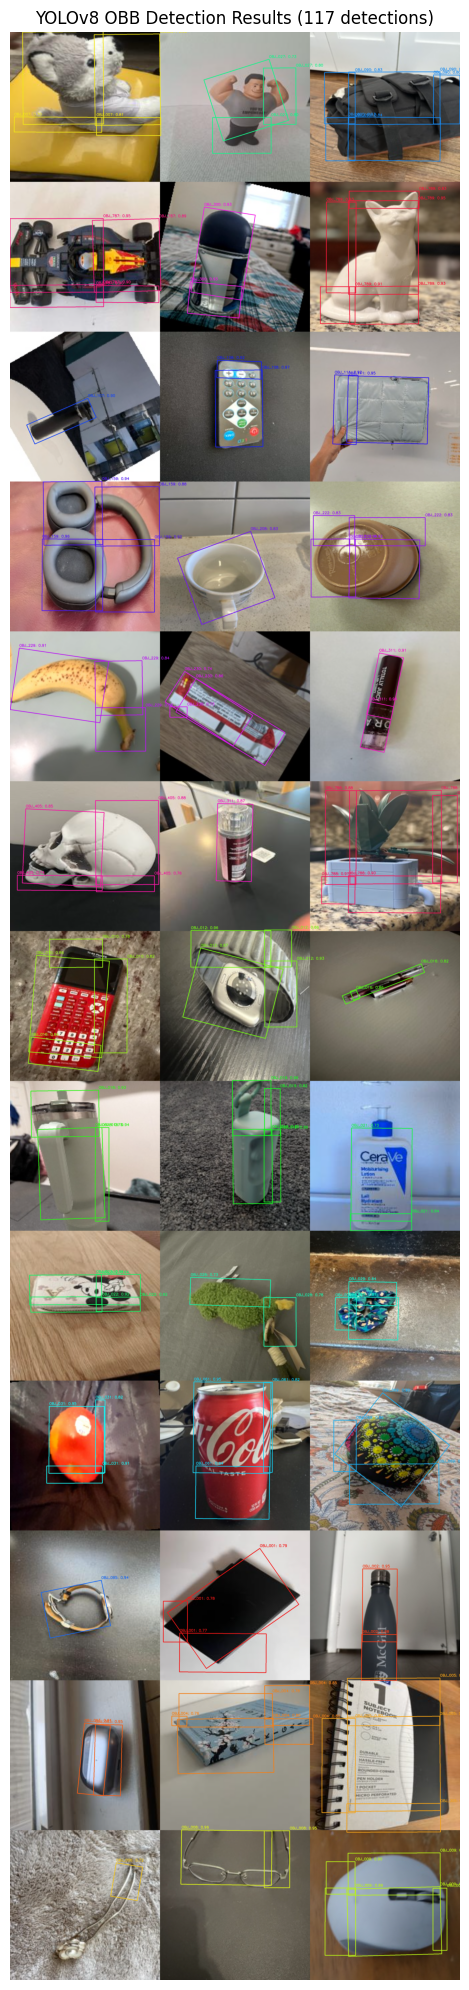

Annotated image saved as 'annotated_result.jpg'


In [ ]:
import cv2
import numpy as np
from PIL import Image as PILImage
import colorsys

img = cv2.imread(image_filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print(f"Drawing {len(all_detections)} detections on image")

class_names = model.names if hasattr(model, 'names') else {}

detected_classes = sorted(set(det['class'] for det in all_detections))
num_classes = len(detected_classes)
color_map = {}
for i, cls_id in enumerate(detected_classes):
    hue = i / max(num_classes, 1)
    r, g, b = colorsys.hsv_to_rgb(hue, 0.9, 0.95)
    color_map[cls_id] = (int(r * 255), int(g * 255), int(b * 255))

for detection in all_detections:
    conf = detection['conf']
    class_id = detection['class']
    class_name = class_names.get(class_id, f'Class {class_id}')
    color = color_map[class_id]

    if detection.get('type') == 'obb':
        corners = detection['corners'].astype(np.int32)
        cv2.polylines(img_rgb, [corners], isClosed=True, color=color, thickness=3)

        label_pt = corners[corners[:, 1].argmin()]
        label = f"{class_name}: {conf:.2f}"
        cv2.putText(img_rgb, label, (int(label_pt[0]), int(label_pt[1]) - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    else:
        x1, y1 = int(detection['x1']), int(detection['y1'])
        x2, y2 = int(detection['x2']), int(detection['y2'])
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 3)

        label = f"{class_name}: {conf:.2f}"
        cv2.putText(img_rgb, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

plt.figure(figsize=(16, 20))
plt.imshow(img_rgb)
plt.title(f"YOLOv8 OBB Detection Results ({len(all_detections)} detections)")
plt.axis('off')
plt.tight_layout()
plt.show()

output_img = PILImage.fromarray(img_rgb)
output_img.save('annotated_result.jpg')
print("Annotated image saved as 'annotated_result.jpg'")